# **Notebook 8 – Distribution Analysis**

In [27]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
# Load dataset
df = pd.read_csv("healthcare_patient_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PatientID      1500 non-null   object 
 1   Age            1500 non-null   int64  
 2   Gender         1500 non-null   object 
 3   Height_cm      1500 non-null   float64
 4   Weight_kg      1500 non-null   float64
 5   BMI            1500 non-null   float64
 6   HeartRate      1500 non-null   int64  
 7   SystolicBP     1500 non-null   int64  
 8   DiastolicBP    1500 non-null   int64  
 9   BloodGlucose   1500 non-null   int64  
 10  Cholesterol    1500 non-null   int64  
 11  Temperature_C  1500 non-null   float64
 12  HospitalDays   1500 non-null   int64  
 13  Diagnosis      1500 non-null   object 
dtypes: float64(4), int64(7), object(3)
memory usage: 164.2+ KB


## **1. Normal Distribution**



**Understand the Concept**

A normal distribution is a symmetric, bell-shaped distribution where most values are concentrated around the center.

In a perfectly normal distribution:

- Mean ≈ Median
- The left and right sides are approximately symmetric
- Extreme values are less common



**Demonstrate the Concept**

We can analyze Height_cm to check whether its values are approximately normally distributed.

**Real-Life Example**

Most patients may have heights around the average value, while very short or very tall heights occur less frequently.

**AI/ML Usage**

Understanding normal distribution helps with:

- Statistical analysis
- Z-Score based outlier detection
- Feature transformation
- Selecting appropriate Machine Learning techniques

In [29]:
# Summary statistics - Height_cm
print(df["Height_cm"].describe())

count    1500.000000
mean      165.040200
std        10.758714
min        18.000000
25%       158.100000
50%       165.150000
75%       171.825000
max       195.000000
Name: Height_cm, dtype: float64


In [30]:
# Skewness
print("Skewness:", df["Height_cm"].skew())

Skewness: -1.656452571460957


In [31]:
# Kurtosis
print("Kurtosis:", df["Height_cm"].kurt())

Kurtosis: 22.483341505943322


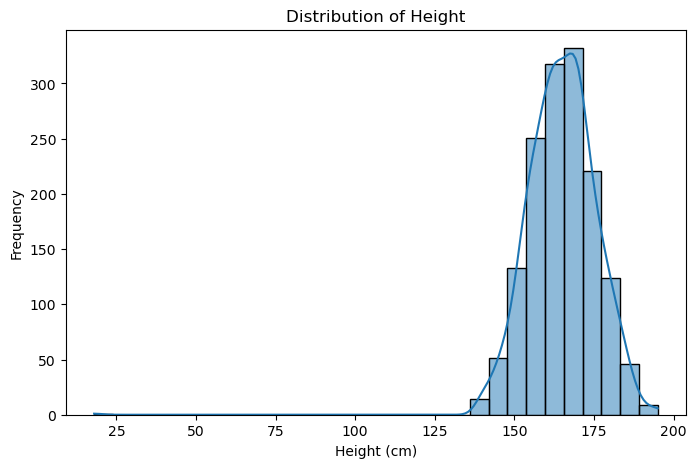

In [32]:
# Histogram with KDE
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Height_cm", kde=True, bins=30)
plt.title("Distribution of Height")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- The histogram shows the shape of the Height_cm distribution.
- If the distribution is approximately bell-shaped, it can be considered approximately normal.
- The mean and median help identify the center.
- The standard deviation shows the spread of the values.
- Skewness close to 0 indicates a more symmetric distribution.
- Extreme values may indicate potential outliers.

## **2. Uniform Distribution**



**Understand the Concept**

- A uniform distribution occurs when values are distributed approximately evenly across a range.
- Each value or range has a similar probability of occurring.



**Demonstrate the Concept**

A uniform distribution is usually represented by a relatively flat pattern.

**Real-Life Example**

For example, if patient appointment slots are assigned randomly and evenly between different time intervals, the values may follow a uniform distribution.

**AI/ML Usage**

Understanding uniform distribution helps with:

- Random data generation
- Simulation
- Sampling
- Testing Machine Learning algorithms

In [33]:
# Create sample  - uniform distribution data
uniform_data = np.random.uniform(low=0, high=100, size=1500)

# Convert to DataFrame
uniform_df = pd.DataFrame({"UniformValues": uniform_data})
uniform_df.head()

,UniformValues
0,72.364866
1,76.854199
2,60.973578
3,3.574609
4,72.001537


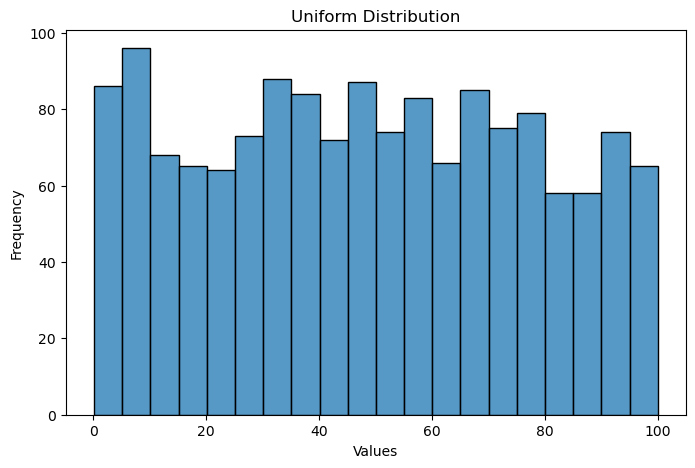

In [34]:
# Visualization - uniform distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=uniform_df, x="UniformValues", bins=20)
plt.title("Uniform Distribution")
plt.xlabel("Values")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- The histogram shows values spread across the selected range.
- The bars are expected to have approximately similar heights.
- There is no strong central peak.
- Small differences occur because the data is randomly generated.

## **3. Skewness**



**Understand the Concept**

Skewness measures the asymmetry of a data distribution.

A distribution can be:

- Positive skew - longer tail on the right
- Negative skew - longer tail on the left
- Near 0 - approximately symmetric



**Demonstrate the Concept**

- We can analyze BloodGlucose to measure the skewness of its distribution.
- A few extremely high BloodGlucose values may create a longer right tail.

**Real-Life Example**

Most patients may have BloodGlucose values around a common range, while a small number of patients may have very high values.

This can result in a right-skewed distribution.

**AI/ML Usage**

Skewness analysis helps with:

- Understanding data distribution
- Detecting extreme values
- Choosing feature transformations
- Improving model performance

In [35]:
# skewness
skewness = df["BloodGlucose"].skew()
print("Skewness:", round(skewness, 2))

Skewness: 0.51


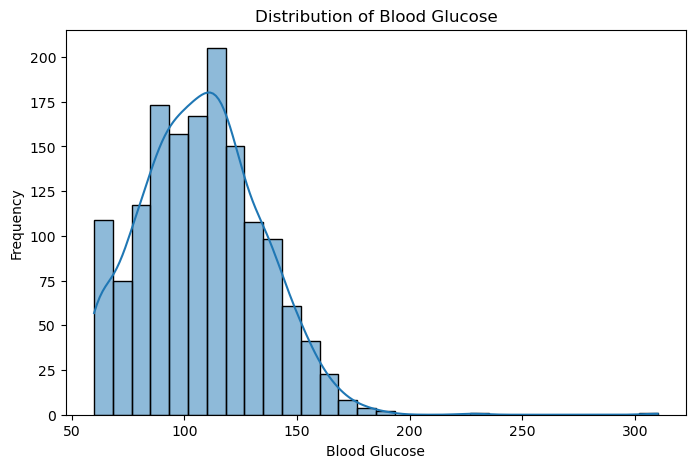

In [36]:
# Histogram
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="BloodGlucose", kde=True, bins=30)
plt.title("Distribution of Blood Glucose")
plt.xlabel("Blood Glucose")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- A positive skewness value indicates a longer right tail.
- A negative skewness value indicates a longer left tail.
- A value close to 0 indicates an approximately symmetric distribution.
- Extreme values can increase the skewness of the distribution.

## **4. Kurtosis**



**Understand the Concept**

Kurtosis measures the shape of a distribution, especially the presence of extreme values in its tails.

Kurtosis can indicate:

- High kurtosis - heavier tails and more extreme values
- Low kurtosis - lighter tails and fewer extreme values
- Near 0 - similar to a normal distribution



**Demonstrate the Concept**

- We can analyze BloodGlucose to understand whether extreme values affect the distribution.
- Very high BloodGlucose values may increase the kurtosis.

**Real-Life Example**

Most patients may have BloodGlucose values within a common range, while a small number may have extremely high values.

These extreme observations can create heavier tails in the distribution.

**AI/ML Usage**

Kurtosis analysis helps with:

- Understanding distribution shape
- Identifying extreme observations
- Detecting heavy-tailed data
- Supporting feature transformation

In [37]:
# kurtosis
kurtosis = df["BloodGlucose"].kurt()
print("Kurtosis:", round(kurtosis, 2))

Kurtosis: 1.86


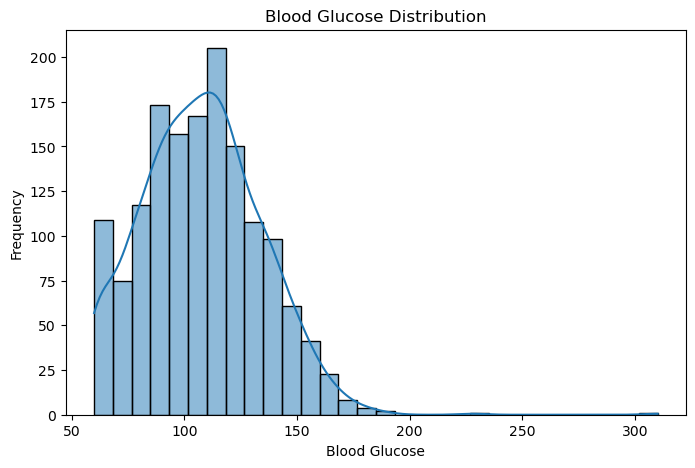

In [38]:
# Visualize the distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="BloodGlucose", kde=True, bins=30)
plt.title("Blood Glucose Distribution")
plt.xlabel("Blood Glucose")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- Most values are between 80 and 150.
- The distribution has a longer right tail.
- Extreme values indicate potential outliers.

## **5. Symmetric Distribution**



**Understand the Concept**

A symmetric distribution has similar shapes on both sides of the center.

The mean and median are usually close to each other.

**Demonstrate the Concept**

We can analyze Height_cm because most values are distributed around the average height.

**Real-Life Example**

Most patients have heights near the average, while very short and very tall heights occur less frequently.

**AI/ML Usage**

Symmetric data is easier to analyze using many statistical techniques.

In [39]:
# mean & median
print("Mean:", round(df["Height_cm"].mean(), 2))
print("Median:", round(df["Height_cm"].median(), 2))

Mean: 165.04
Median: 165.15


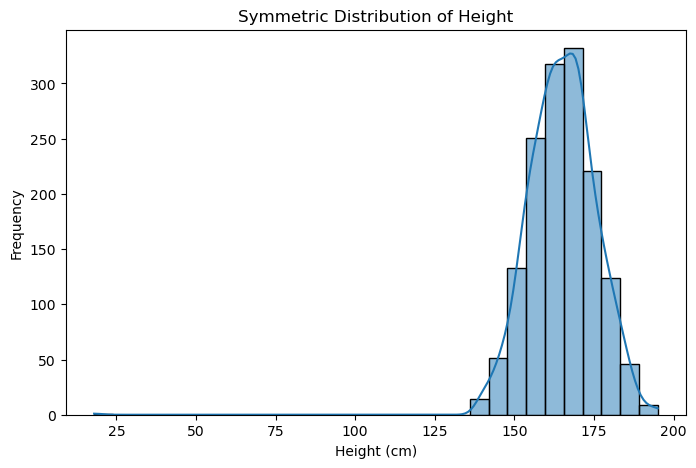

In [40]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Height_cm", kde=True, bins=30)
plt.title("Symmetric Distribution of Height")
plt.xlabel("Height (cm)")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- The distribution is approximately symmetric.
- Most values are concentrated around the center.
- The mean and median are close to each other.

## **6. Left-Skewed Distribution**



**Understand the Concept**

- A left-skewed distribution has a longer tail on the left side.
- Most values are concentrated toward the right.



**Demonstrate the Concept**

**Real-Life Example**

if most patients have high health scores and only a few have very low scores, the distribution may be left-skewed.

**AI/ML Usage**

Understanding skewness helps in selecting suitable transformations and statistical methods.

In [41]:
# Create left-skewed distribution
left_skewed_data = np.random.beta(a=5, b=2, size=1500) * 100
left_skewed_df = pd.DataFrame({"HealthScore": left_skewed_data})
print("Skewness:", round(left_skewed_df["HealthScore"].skew(), 2))

Skewness: -0.65


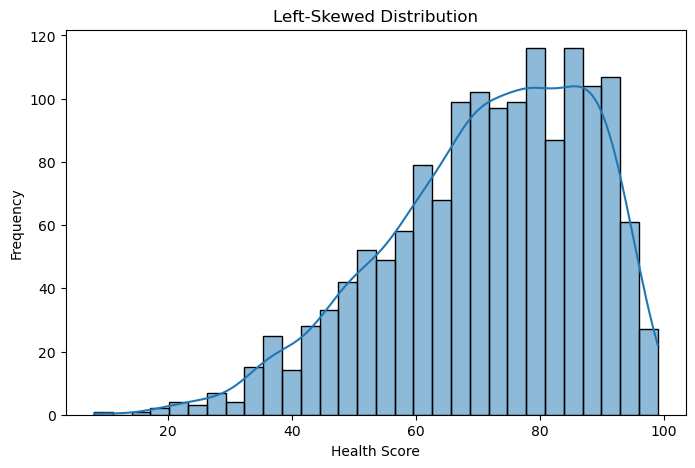

In [42]:
plt.figure(figsize=(8, 5))
sns.histplot(data=left_skewed_df, x="HealthScore", kde=True, bins=30)
plt.title("Left-Skewed Distribution")
plt.xlabel("Health Score")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- The distribution has a longer tail on the left side.
- Most values are concentrated toward the right.
- The skewness value is negative.

## **7. Right-Skewed Distribution**



**Understand the Concept**

- A right-skewed distribution has a longer tail on the right side.
- Most values are concentrated toward the left.



**Demonstrate the Concept**

We can analyze HospitalDays because most patients have a small number of hospital days, while a few patients may have much longer stays.

**Real-Life Example**

Most patients may stay in the hospital for only a few days, while a small number may require longer treatment.

**AI/ML Usage**

Right-skewed data may require transformation to reduce skewness and improve statistical analysis or model performance.

In [43]:
# skewness
skewness = df["HospitalDays"].skew()
print("Skewness:", round(skewness, 2))

Skewness: 3.91


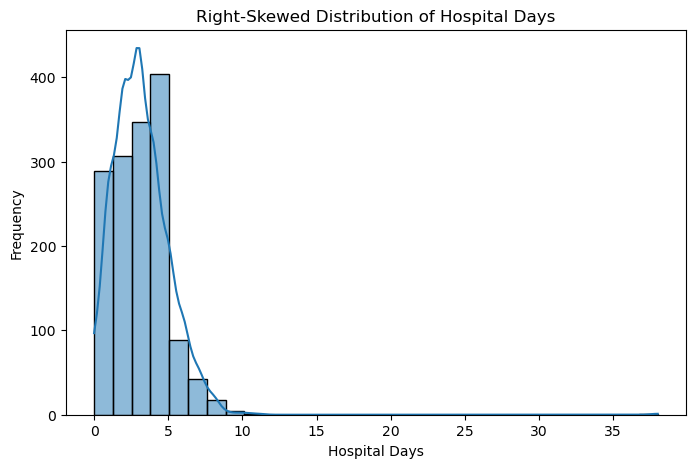

In [44]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="HospitalDays", kde=True, bins=30)
plt.title("Right-Skewed Distribution of Hospital Days")
plt.xlabel("Hospital Days")
plt.ylabel("Frequency")
plt.show()

**Interpretation**

- Most values are concentrated at lower hospital stay durations.
- The distribution has a longer tail on the right side.
- The skewness value is positive.
- A few patients with long hospital stays may be potential outliers.